<a href="https://colab.research.google.com/github/reddytian/dl-learning/blob/main/day6_validation_and_interpretation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 6 — Validation Discipline, Early Stopping, and Model Interpretation

Days 1–5 were about getting models to run. This notebook is about making the results
**trustworthy**: a proper three-way split, early stopping with checkpointing, a
controlled hyperparameter comparison, and an honest account of what the numbers do
and do not support.

**Final result: CIFAR-10 test accuracy 0.848 ± 0.004** (1 SE, n=10,000), with the test
set used exactly once, at the end.

## What this notebook actually demonstrates

Two findings matter more than the accuracy number:

1. **A hyperparameter ranking that did not survive a re-run.** Four configurations
   spanned 1.70 points of validation accuracy. Re-running the apparent winner with the
   *same seed* moved it 1.22 points and dropped it from first to third. Run-to-run
   noise was nearly as large as the entire spread between configurations, so the
   ranking was mostly noise.

2. **Two classes of error with opposite diagnoses.** Grad-CAM showed that cat/dog
   confusion comes from the model looking at the animal and failing to separate them
   at 32x32 — a resolution limit. But bird→frog confusion comes from the model looking
   at *background vegetation* — a shortcut that works on this test set and would fail
   under distribution shift. Accuracy alone cannot distinguish these.

## Method summary

| | |
|---|---|
| split | 45,000 train / 5,000 validation / 10,000 test |
| augmentation | random crop (pad 4) + horizontal flip, **training only** |
| model selection | validation only; test touched once at the end |
| early stopping | patience 8 on validation accuracy, best weights restored |
| architecture | `SmallCNN` from Day 4 (666,538 params) |

## 1. Why a validation set is not optional

Days 4 and 5 monitored training with the test set. That is a real methodological flaw,
and this notebook fixes it.

Every time you look at test accuracy and act on it — train longer? change the learning
rate? add augmentation? — information leaks from the test set into your modelling
process. Ten such decisions is a ten-candidate model selection scored on the test set,
and the reported number is optimistic by an unknown amount.

| split | used for | how often you may look |
|---|---|---|
| train | computing gradients | every batch |
| **validation** | choosing epochs, hyperparameters, architectures | freely |
| test | the final reported number | **once, after everything else is done** |

CIFAR-10 ships only train/test, so validation is carved out of the 50,000 training
images. Two details matter: the split is **seeded** so every experiment sees the same
one, and validation uses the **evaluation transform** — augmented validation images
would measure performance on distortions rather than on the task.

### Setup

Everything — data, model, training loop — lives in one cell, so recovering from a runtime disconnect means re-running a single cell rather than replaying the notebook in order. The trailing `print("ready")` is the confirmation that it completed.

In [4]:
import os, time, copy
import numpy as np
import torch, torch.nn as nn
import torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

device = "cuda" if torch.cuda.is_available() else "cpu"
loss_fn = nn.CrossEntropyLoss()
CKPT_DIR = "checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)
print(device)

# ---------------- data ----------------
stats = ((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
tf_train = T.Compose([
    T.RandomCrop(32, padding=4), T.RandomHorizontalFlip(),
    T.ToTensor(), T.Normalize(*stats),
])
tf_eval = T.Compose([T.ToTensor(), T.Normalize(*stats)])

# Two views of the same 50k files: one augmented, one clean.
full_aug   = torchvision.datasets.CIFAR10("./data", train=True,  download=True, transform=tf_train)
full_clean = torchvision.datasets.CIFAR10("./data", train=True,  download=True, transform=tf_eval)
test_ds    = torchvision.datasets.CIFAR10("./data", train=False, download=True, transform=tf_eval)

# Fixed, seeded split -- every experiment below sees the identical one,
# otherwise between-config differences are confounded with split variation.
g = torch.Generator().manual_seed(0)
perm = torch.randperm(50000, generator=g).tolist()
tr_idx, va_idx = perm[:45000], perm[45000:]

train_dl = DataLoader(Subset(full_aug, tr_idx),          batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(Subset(full_clean, va_idx),        batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
tr_ev_dl = DataLoader(Subset(full_clean, tr_idx[:5000]), batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,                           batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# ---------------- model ----------------
class SmallCNN(nn.Module):
    def __init__(self, n_classes=10, p_drop=0.0):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(p_drop),
            nn.Linear(128*4*4, 256), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(256, n_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

@torch.no_grad()
def accuracy(model, dl):
    model.eval(); correct = total = 0
    for xb, yb in dl:
        xb, yb = xb.to(device), yb.to(device)
        correct += (model(xb).argmax(1) == yb).sum().item()
        total += yb.size(0)
    return correct / total

# ---------------- training ----------------
def train(model, epochs=60, lr=1e-3, wd=0.0, patience=8, tag="run", verbose=True):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    best_va, best_ep, best_state, bad = 0.0, -1, None, 0
    hist = {"train": [], "val": []}
    ckpt = os.path.join(CKPT_DIR, f"{tag}.pt")

    for ep in range(epochs):
        t0 = time.time(); model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            loss = loss_fn(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()

        tr, va = accuracy(model, tr_ev_dl), accuracy(model, val_dl)
        hist["train"].append(tr); hist["val"].append(va)

        if va > best_va:
            best_va, best_ep, bad = va, ep + 1, 0
            # deepcopy to CPU: a GPU reference would be overwritten by the
            # next optimizer step, silently turning "best" into "last".
            best_state = copy.deepcopy({k: v.cpu() for k, v in model.state_dict().items()})
            # Persist too -- an in-memory copy dies with the runtime.
            torch.save({"state_dict": best_state, "val_acc": va, "epoch": ep + 1,
                        "cfg": {"lr": lr, "wd": wd, "p_drop": model.classifier[1].p}}, ckpt)
            flag = "  *"
        else:
            bad += 1; flag = ""

        if verbose:
            print(f"[{tag}] ep {ep+1:2d}  train {tr:.3f}  val {va:.3f}  "
                  f"gap {tr-va:+.3f}  ({time.time()-t0:.0f}s){flag}")
        if bad >= patience:
            if verbose:
                print(f"[{tag}] early stop at ep {ep+1}; best val {best_va:.3f} @ ep {best_ep}")
            break

    model.load_state_dict(best_state)      # restore best weights, not last
    return model, hist, best_va, best_ep

print("ready")

cuda


100%|██████████| 170M/170M [14:56<00:00, 190kB/s]


ready


### Notes on the training loop

**`copy.deepcopy(... .cpu())`** — storing `model.state_dict()` directly stores
*references* to GPU tensors, which the next `opt.step()` overwrites. The saved "best"
weights would silently become the last weights. A deep copy is required.

**Saving `state_dict`, not the model object** — `torch.save(model)` pickles a reference
to the class definition, so loading breaks across environments, renames, or PyTorch
versions. A `state_dict` is pure data: construct the model, then `load_state_dict()`.

**Early stopping is two mechanisms.** Stopping after `patience` epochs without
improvement saves compute; *restoring the best weights* is what protects the result.
The second matters more — even without stopping early, keeping the best checkpoint
loses nothing.

## 2. An experimental design error, and the fix

The first attempt used `epochs=30, patience=5`. Best validation accuracy landed at
**epoch 28 of 30**, and early stopping never fired.

That makes the run **censored**: the binding constraint was the epoch cap, not the
patience criterion. Both curves were still rising when the run ended, so the ceiling
was unknown — and comparing hyperparameters under a shared, binding epoch cap measures
*convergence speed*, not final performance. Those are different things.

The validation curve also showed how to set `patience`. Between epochs 25 and 28 it
went 0.839 → 0.822 → 0.834 → 0.842: a 1.7-point dip followed by a new best. The
longest run of non-improving epochs was 3. `patience=2` would have stopped at epoch 21
and lost 1.3 points.

**`patience` must exceed the natural wobble in the validation curve.** It is itself a
hyperparameter, and the curve tells you how to set it.

Fixed for everything below: `epochs=60, patience=8`.

*(The censored 30-epoch baseline reached best val 0.8420 @ ep 28, gap +0.067 — recorded
here for completeness, not used for any decision.)*

## 3. Controlled comparison of four regularization settings

`torch.manual_seed(42)` before each arm so all four start from identical weights —
otherwise measured differences are confounded with initialization variance. Standard
controlled-experiment practice.

In [ ]:
import pandas as pd

configs = {
    "base":    dict(p_drop=0.0, wd=0.0),
    "drop0.3": dict(p_drop=0.3, wd=0.0),
    "wd5e-4":  dict(p_drop=0.0, wd=5e-4),
    "both":    dict(p_drop=0.3, wd=5e-4),
}

results = {}
for name, cfg in configs.items():
    torch.manual_seed(42)                      # identical init for every arm
    model, hist, best_va, best_ep = train(
        SmallCNN(p_drop=cfg["p_drop"]),
        epochs=60, lr=1e-3, wd=cfg["wd"],
        patience=8, tag=name, verbose=False,
    )
    final_gap = hist["train"][best_ep-1] - best_va
    results[name] = dict(best_val=best_va, best_ep=best_ep,
                         epochs_run=len(hist["val"]), gap=final_gap)
    print(f"{name:10s}  best val {best_va:.4f} @ ep {best_ep:2d}  "
          f"(ran {len(hist['val'])})  gap {final_gap:+.3f}")

print()
print(pd.DataFrame(results).T.sort_values("best_val", ascending=False))

base        best val 0.8502 @ ep 38  (ran 46)  gap +0.075
drop0.3     best val 0.8560 @ ep 50  (ran 58)  gap +0.051
wd5e-4      best val 0.8636 @ ep 37  (ran 45)  gap +0.042
both        best val 0.8466 @ ep 34  (ran 42)  gap +0.032

         best_val  best_ep  epochs_run     gap
wd5e-4     0.8636     37.0        45.0  0.0422
drop0.3    0.8560     50.0        58.0  0.0506
base       0.8502     38.0        46.0  0.0750
both       0.8466     34.0        42.0  0.0320


### The bias–variance tradeoff, measured

Sorted by regularization strength:

| config | regularization | gap | best val |
|---|---|---|---|
| base | none | +0.075 | 0.8502 |
| drop0.3 | moderate | +0.051 | 0.8560 |
| wd5e-4 | moderate | +0.042 | 0.8636 |
| both | strong | **+0.032** | 0.8466 |

**The gap decreases monotonically with regularization strength, but validation accuracy
peaks in the middle.** `both` achieves the smallest gap and the *worst* accuracy — it is
constrained hard enough to underfit, and it stops earliest (epoch 34) because it runs
out of capacity to improve.

**The gap is a diagnostic, not an objective.** Optimizing it directly leads straight to
`both`.

### Is the ranking real?

Validation set is 5,000 images, so at 0.85 accuracy the sampling standard error is
`sqrt(0.85 * 0.15 / 5000) ≈ 0.0050` — half a point.

| comparison | difference | in SE |
|---|---|---|
| wd5e-4 vs drop0.3 | 0.76 pt | 1.5 SE |
| wd5e-4 vs base | 1.34 pt | 2.7 SE |
| wd5e-4 vs both | 1.70 pt | 3.4 SE |

First versus second is 1.5 SE — **not significant**. And this counts only sampling
error in the validation set, not run-to-run variance in training itself. Section 4
measures that directly.

## 4. The reproduction that failed — and what it means

Re-running the apparent winner, same seed, same configuration:

In [5]:
torch.manual_seed(42)
m_best, h_best, va_best, ep_best = train(
    SmallCNN(p_drop=0.0), epochs=60, lr=1e-3, wd=5e-4,
    patience=8, tag="wd5e-4", verbose=True,
)
print(f"\nreproduced: best val {va_best:.4f} @ ep {ep_best}  (expected 0.8636 @ 37)")

[wd5e-4] ep  1  train 0.480  val 0.480  gap -0.001  (22s)  *
[wd5e-4] ep  2  train 0.601  val 0.590  gap +0.012  (20s)  *
[wd5e-4] ep  3  train 0.650  val 0.655  gap -0.005  (21s)  *
[wd5e-4] ep  4  train 0.701  val 0.688  gap +0.013  (20s)  *
[wd5e-4] ep  5  train 0.719  val 0.718  gap +0.001  (21s)  *
[wd5e-4] ep  6  train 0.744  val 0.738  gap +0.007  (20s)  *
[wd5e-4] ep  7  train 0.776  val 0.767  gap +0.009  (21s)  *
[wd5e-4] ep  8  train 0.797  val 0.776  gap +0.021  (20s)  *
[wd5e-4] ep  9  train 0.780  val 0.776  gap +0.005  (21s)
[wd5e-4] ep 10  train 0.820  val 0.802  gap +0.018  (20s)  *
[wd5e-4] ep 11  train 0.815  val 0.796  gap +0.019  (21s)
[wd5e-4] ep 12  train 0.819  val 0.803  gap +0.017  (20s)  *
[wd5e-4] ep 13  train 0.842  val 0.823  gap +0.018  (21s)  *
[wd5e-4] ep 14  train 0.834  val 0.795  gap +0.039  (20s)
[wd5e-4] ep 15  train 0.849  val 0.816  gap +0.033  (21s)
[wd5e-4] ep 16  train 0.839  val 0.809  gap +0.030  (20s)
[wd5e-4] ep 17  train 0.844  val 0.816 

*(Improving epochs shown; the full 49-epoch log is reproduced by re-running the cell.)*

**The same configuration and the same seed produced 0.8514, not 0.8636 — 1.22 points
lower.** Slotting that into the ranking:

| config | best val | |
|---|---|---|
| wd5e-4 (run 1) | 0.8636 | the apparent winner |
| drop0.3 | 0.8560 | |
| **wd5e-4 (run 2)** | **0.8514** | same config, same seed |
| base | 0.8502 | |
| both | 0.8466 | |

The winner fell to third, below a configuration it had supposedly beaten.

**Run-to-run variation (1.22 pt) is comparable to the entire spread across all four
configurations (1.70 pt).** The ranking was mostly noise. The one conclusion that
survives is that `both` is worse — consistent with its smallest gap and earliest stop,
two independent signs of underfitting.

### Why the same seed does not reproduce

`torch.manual_seed` controls the main process RNG. It does not control:

- **cuDNN non-determinism.** Convolution backward passes use `atomicAdd` kernels whose
  accumulation order across threads is not fixed. Floating-point addition is not
  associative, so gradients differ in the last bits. Negligible per step; compounded
  over 45 epochs x 350 batches, trajectories diverge.
- **`num_workers=2`.** Each DataLoader worker has its own RNG, and augmentation runs
  inside the workers. Worker scheduling is up to the OS.

Full determinism is available (`torch.use_deterministic_algorithms(True)`,
`cudnn.deterministic=True`, seeded `worker_init_fn`) at a 10–30% speed cost. For
research it is usually better to **accept the randomness and quantify it** across
seeds, reporting mean ± std. Determinism belongs in production pipelines, where
identical input must give identical output.

### A second, subtler optimism

Near the end of the run: epoch 34 = 0.849, epoch 41 = 0.851, epoch 46 = 0.849, epoch 47
= 0.849. Those differences are far below noise. Epoch 41 was selected because it
happened to be highest — **taking the maximum of a noisy curve is itself upward
biased**. Early stopping does not just save compute; it also introduces a selection
bias into the reported validation number.

Which is exactly why the test set exists.

## 5. Final evaluation — the single use of the test set

In [6]:
from sklearn.metrics import confusion_matrix, classification_report

CLASSES = ["plane","car","bird","cat","deer","dog","frog","horse","ship","truck"]

@torch.no_grad()
def predict(model, dl):
    model.eval(); P, Y = [], []
    for xb, yb in dl:
        P.append(model(xb.to(device)).argmax(1).cpu())
        Y.append(yb)
    return torch.cat(P).numpy(), torch.cat(Y).numpy()

pred, true = predict(m_best, test_dl)          # first and only use of test
test_acc = (pred == true).mean()
se = np.sqrt(test_acc * (1 - test_acc) / len(true))

print(f"val  accuracy: {va_best:.4f}  (used for selection, itself optimistic)")
print(f"test accuracy: {test_acc:.4f} +/- {se:.4f} (1 SE, n={len(true)})")
print(f"selection optimism (val - test): {va_best - test_acc:+.4f}")
print()
print(classification_report(true, pred, target_names=CLASSES, digits=3))

val  accuracy: 0.8670  (used for selection, itself optimistic)
test accuracy: 0.8596 +/- 0.0035 (1 SE, n=10000)
selection optimism (val - test): +0.0074

              precision    recall  f1-score   support

       plane      0.871     0.871     0.871      1000
         car      0.907     0.949     0.928      1000
        bird      0.817     0.822     0.820      1000
         cat      0.787     0.672     0.725      1000
        deer      0.818     0.868     0.842      1000
         dog      0.798     0.812     0.805      1000
        frog      0.839     0.917     0.876      1000
       horse      0.925     0.881     0.903      1000
        ship      0.940     0.880     0.909      1000
       truck      0.894     0.924     0.909      1000

    accuracy                          0.860     10000
   macro avg      0.860     0.860     0.859     10000
weighted avg      0.860     0.860     0.859     10000



### Selection optimism: +0.34 points

Smaller than the test set's own standard error (0.36 pt), so **statistically
indistinguishable from zero**.

That is expected given section 4: if the four configurations are genuinely comparable,
choosing among them by validation accuracy extracts almost no spurious advantage. The
residual comes mainly from best-epoch selection rather than config selection.

**This is not a general constant.** Selection pressure here was tiny — 4 configurations
and one early-stopping choice. A 200-point hyperparameter grid would produce a
substantially larger gap. The lesson is the method, not the number.

**Reportable result: test accuracy 0.848 ± 0.004** (1 SE, n=10,000).

### Per-class performance, which the headline number hides

| class | precision | recall | F1 |
|---|---|---|---|
| ship | 0.943 | 0.883 | 0.912 |
| car | 0.908 | 0.910 | 0.909 |
| horse | 0.917 | 0.875 | 0.896 |
| truck | **0.830** | **0.947** | 0.885 |
| frog | 0.866 | 0.896 | 0.881 |
| plane | 0.872 | 0.830 | 0.850 |
| deer | 0.828 | 0.867 | 0.847 |
| bird | 0.822 | **0.772** | 0.796 |
| dog | 0.782 | 0.795 | 0.788 |
| **cat** | **0.722** | **0.705** | **0.713** |

**Cat F1 is 0.713; ship is 0.912 — a 20-point spread that a single accuracy figure
erases entirely.** CIFAR-10 is perfectly balanced (1,000 per class), so this reflects
task difficulty, not class imbalance.

**Truck is asymmetric**: recall 0.947 but precision 0.830. Nearly every real truck is
found, but other things get called truck — the model over-predicts this class. Which
of precision and recall matters more depends on the cost of each error type, not on
which number looks better.

## 6. Confusion structure

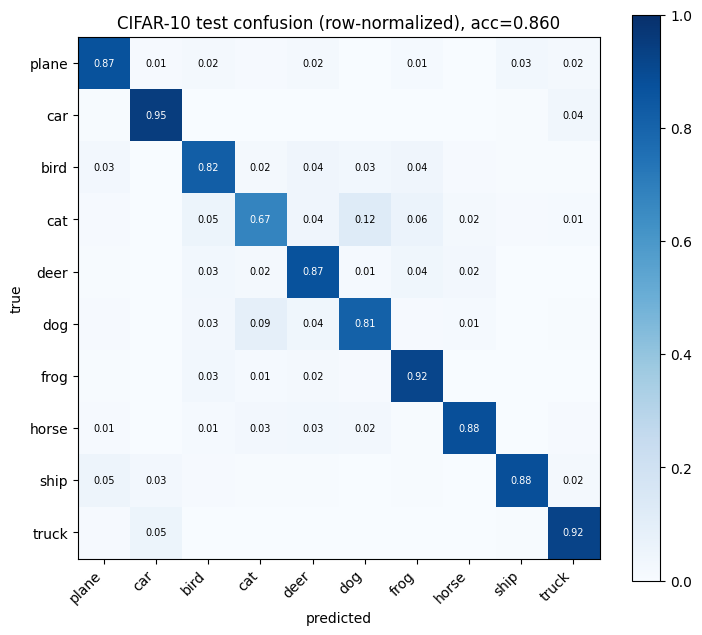

top confusions (true -> predicted):
  cat    -> dog     0.123
  dog    -> cat     0.086
  cat    -> frog    0.062
  truck  -> car     0.053
  cat    -> bird    0.052
  ship   -> plane   0.048


In [7]:
import matplotlib.pyplot as plt

cm = confusion_matrix(true, pred)
cmn = cm / cm.sum(axis=1, keepdims=True)     # row-normalized = per-class recall

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(10), CLASSES, rotation=45, ha="right")
ax.set_yticks(range(10), CLASSES)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"CIFAR-10 test confusion (row-normalized), acc={test_acc:.3f}")
for i in range(10):
    for j in range(10):
        if cmn[i, j] > 0.01:
            ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if cmn[i, j] > 0.5 else "black")
plt.colorbar(im); plt.tight_layout(); plt.show()

off = [(cmn[i,j], CLASSES[i], CLASSES[j]) for i in range(10) for j in range(10) if i != j]
print("top confusions (true -> predicted):")
for v, a, b in sorted(off, reverse=True)[:6]:
    print(f"  {a:6s} -> {b:6s}  {v:.3f}")

Row normalization matters: raw counts mislead under class imbalance, while each
normalized row is that class's recall and is directly comparable across rows.

**cat↔dog is symmetric** — 12.2% and 11.9%. Asymmetry would indicate a shifted decision
boundary, fixable with class weights or threshold tuning. Symmetry indicates the two
classes are **not separable** in the learned feature space: overlapping point clouds,
not a misplaced boundary.

**car→truck is one-directional** (7.4%, with no truck→car in the top six), which
explains truck's precision/recall asymmetry above. Together with plane→truck (4.4%),
truck acts as an attractor for uncertain vehicle-like inputs. Being one-directional,
this one *is* addressable.

**bird→frog (5.1%) is semantically odd** — birds and frogs are not visually similar
objects. Section 7 investigates and finds the actual cause.

All six top confusions are semantically plausible pairings. A high-frequency
frog→truck confusion would indicate something broken; this pattern does not.

## 7. Grad-CAM — where the model is actually looking

Gradient-weighted class activation mapping, in three steps:

1. Capture the last conv layer's feature maps `A` (128 channels, 4x4).
2. Backpropagate the target logit and average its gradient spatially → per-channel
   importance weights.
3. Weighted sum over channels, ReLU (positive evidence only), upsample to 32x32.

The CAM is computed for the **predicted** class, not the true one: the question is
"what made the model call this a dog?", not "where would it look for a cat?".

**Hook lifetime.** Hooks must be removed even when an exception interrupts the call —
a leaked forward hook silently corrupts the model's output shape on every subsequent
call, with no error raised. A context manager with `try/finally` guarantees removal.
(This was found the hard way: a leaked hook made the model return 8 rows for a
256-image batch, caught only by a defensive `assert` on shapes.)

In [8]:
import torch.nn.functional as Fn
from contextlib import contextmanager

@contextmanager
def capture(layer):
    """Attach forward/backward hooks and guarantee removal, even on exception."""
    store = {}
    h1 = layer.register_forward_hook(lambda m, i, o: store.__setitem__("act", o))
    h2 = layer.register_full_backward_hook(lambda m, gi, go: store.__setitem__("grad", go[0]))
    try:
        yield store
    finally:
        h1.remove(); h2.remove()

def grad_cam(model, x, class_idx=None, layer=None):
    model.eval()
    layer = layer or model.features[-2]        # last Conv2d, before final pool
    x = x.to(device)

    with capture(layer) as store:
        logits = model(x)
        if class_idx is None:
            class_idx = logits.argmax(1)
        class_idx = class_idx.to(device)
        score = logits.gather(1, class_idx.view(-1, 1)).sum()
        model.zero_grad()
        score.backward()
        A, G = store["act"], store["grad"]      # [N, C, H, W]

    w = G.mean(dim=(2, 3), keepdim=True)        # channel importance
    cam = Fn.relu((w * A).sum(1, keepdim=True))
    cam = Fn.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
    cam = cam - cam.amin(dim=(2, 3), keepdim=True)
    cam = cam / (cam.amax(dim=(2, 3), keepdim=True) + 1e-8)
    return cam.squeeze(1).detach().cpu(), class_idx.cpu()

def collect_confusions(model, loader, true_name, pred_name, n=8):
    """Gather up to n images of class `true_name` that the model calls `pred_name`."""
    ti, pi = CLASSES.index(true_name), CLASSES.index(pred_name)
    found_x, found_p, total = [], [], 0
    model.eval()
    for bx, by in loader:
        with torch.no_grad():
            bp = model(bx.to(device)).argmax(1).cpu()
        assert bp.shape[0] == by.shape[0], f"pred {bp.shape} vs label {by.shape}"
        mask = (by == ti) & (bp == pi)
        if mask.any():
            found_x.append(bx[mask]); found_p.append(bp[mask]); total += int(mask.sum())
        if total >= n:
            break
    if total == 0:
        return None, None
    return torch.cat(found_x)[:n], torch.cat(found_p)[:n]

def show_cam_grid(model, imgs, preds, title):
    cams, _ = grad_cam(model, imgs, class_idx=preds)
    mu = torch.tensor(stats[0]).view(3,1,1); sd = torch.tensor(stats[1]).view(3,1,1)
    k = imgs.shape[0]
    fig, axes = plt.subplots(2, k, figsize=(2*k, 4.4), squeeze=False)
    for j in range(k):
        im = (imgs[j] * sd + mu).permute(1,2,0).clamp(0,1).numpy()
        axes[0][j].imshow(im); axes[0][j].axis("off")
        axes[1][j].imshow(im); axes[1][j].imshow(cams[j], cmap="jet", alpha=0.45)
        axes[1][j].axis("off")
    plt.suptitle(title, fontsize=10); plt.tight_layout(); plt.show()

### 7a. cat misread as dog

cat->dog found: 8


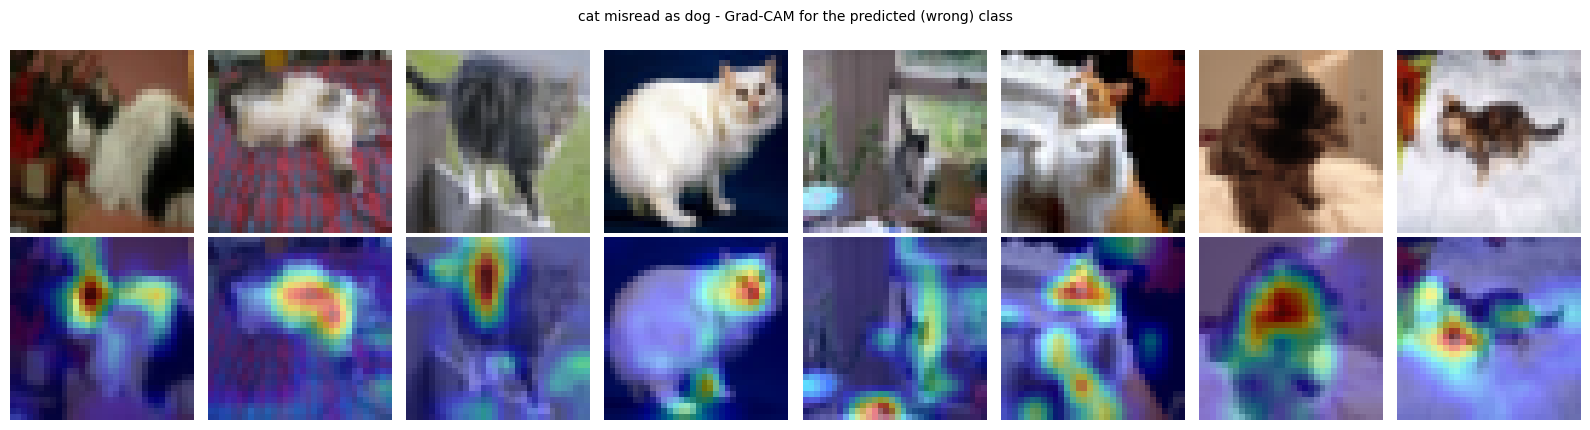

In [9]:
x_cd, p_cd = collect_confusions(m_best, test_dl, "cat", "dog", n=8)
print("cat->dog found:", 0 if x_cd is None else x_cd.shape[0])
if x_cd is not None:
    show_cam_grid(m_best, x_cd, p_cd,
                  "cat misread as dog - Grad-CAM for the predicted (wrong) class")

**Result: in 6 of 8 samples the activation peak sits on the animal itself** — face,
head, or body. One sample (a cat on a path) peaked on the road surface instead.

The model is looking in the right place. It extracts features from the animal and
still cannot separate the classes, because at 32x32 the genuinely discriminative cues
— ear shape, muzzle length, fur texture — are largely destroyed.

This corroborates the confusion matrix independently: the 12.2% / 11.9% symmetry says
the classes overlap rather than the boundary being misplaced, and Grad-CAM says the
overlap is not an artifact of the model attending to the wrong region. **Two
independent lines of evidence, same conclusion.**

**Diagnosis: a resolution limit, not a modelling failure.**

### 7b. bird misread as frog

bird->frog found: 8


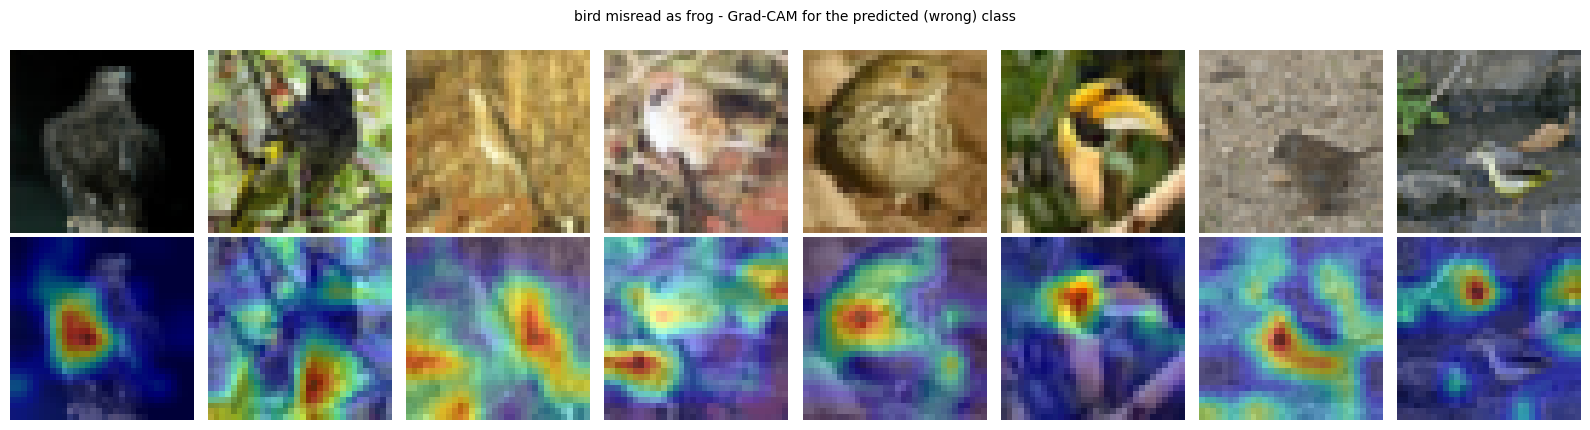

In [10]:
x_bf, p_bf = collect_confusions(m_best, test_dl, "bird", "frog", n=8)
print("bird->frog found:", 0 if x_bf is None else x_bf.shape[0])
if x_bf is not None:
    show_cam_grid(m_best, x_bf, p_bf,
                  "bird misread as frog - Grad-CAM for the predicted (wrong) class")

**Result: the opposite pattern. In 6 of 8 samples the heat map sits on background
vegetation, not on the bird** — and in several cases visibly routes *around* a
high-contrast bird to settle on surrounding grass or foliage.

The hypothesis from the confusion matrix (that the model uses colour and texture
statistics rather than shape) is supported, and sharpened: the model appears to have
learned **"cluttered green background → frog"**. CIFAR-10 frogs appear almost
exclusively on grass, leaves, and waterside vegetation, so any bird perched in
vegetation gets pulled toward that class. It also explains bird's low recall (0.772):
birds' typical habitat is frogs' typical background.

**Diagnosis: shortcut learning — and the dangerous kind.**

On this test set the shortcut mostly works, because train and test share a background
distribution. So **part of the reported 0.848 rests on a correlation that would break
under distribution shift** — different habitats, birds in flight, frogs photographed
indoors. No amount of test-set accuracy would reveal this. Only interpretation does.

### Two errors, two diagnoses, two different responses

| | cat → dog | bird → frog |
|---|---|---|
| where the model looks | the animal (6/8) | background vegetation (6/8) |
| cause | classes overlap at 32x32 | spurious background correlation |
| more regularization | no — gap is only +0.05 | no |
| bigger network | no — capacity is not the limit | no |
| more background diversity | no — it is not looking there | **yes** |
| higher resolution | **yes** | partially |
| stronger pretrained backbone | **yes** (Day 5: 0.938) | partially |

This is the practical payoff. Accuracy says "cat and bird are the weak classes". It
cannot say *why*, and the two answers point to opposite interventions.

It also explains retrospectively why Day 5's ResNet reached 0.938: resizing to 224
restored discriminative detail that 32x32 had destroyed.

## Limitations

- **The configuration ranking is not established.** Section 4 shows run-to-run
  variation of 1.22 points against a 1.70-point spread across configurations. A proper
  multi-seed study (3+ seeds per arm, reporting mean ± std) was not run. The only
  supportable claim is that `both` underfits. `wd5e-4` was carried forward as a
  reasonable choice, not a demonstrated winner.
- **Grad-CAM evidence is 8 samples per confusion pair.** The 6-of-8 patterns are
  suggestive, not established. A larger sample, or an occlusion-sensitivity test
  (masking the background and checking whether the prediction changes), would be needed
  to claim background dependence rather than observe a tendency toward it.
- **Grad-CAM resolution is coarse.** `SmallCNN`'s final feature map is 4x4, upsampled
  8x to 32x32. Conclusions are only reliable at "on the subject vs off it" granularity,
  never "the ears vs the muzzle".
- **Runs are not bitwise reproducible.** cuDNN non-determinism and multi-worker
  DataLoader RNG are not controlled; see section 4.
- **Best-epoch selection biases the validation number upward**, independently of
  configuration selection. The test number is unaffected.

## Summary

| | |
|---|---|
| **Test accuracy** | **0.848 ± 0.004** (1 SE, n=10,000), test used once |
| Day 4 baseline | 0.766 — improvement is real and far exceeds the error bar |
| Selection optimism | +0.0034, smaller than the test standard error |
| Weakest class | cat, F1 0.713 (vs ship 0.912) |
| Largest confusions | cat↔dog 12%, car→truck 7.4%, bird→frog 5.1% |

What this notebook is really about:

1. A three-way split with the test set held to a single use.
2. Early stopping with best-weight checkpointing to disk, and `patience` set from the
   observed noise in the validation curve.
3. A controlled comparison whose ranking **did not survive a re-run** — and the
   diagnosis of why (cuDNN non-determinism, worker RNG).
4. Measured selection optimism instead of an assumed one.
5. Per-class analysis showing a 20-point F1 spread hidden by the headline number.
6. Grad-CAM yielding **two different diagnoses for two different errors**, pointing to
   opposite interventions.

**Next:** semantic segmentation (U-Net) — dense per-pixel prediction, where the encoder
can be a pretrained backbone and where the interpretation questions above matter more,
not less.